[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/02_data_science/A1_forecasting_classical.ipynb)

> 📎 **Appendix notebook — reference style.** This is one of the optional appendices (see `README.md`). Unlike the main course notebooks, appendices are written as a demo / reference: they focus on *seeing* a library at work rather than on interactive exercises. You won't find the full Solution / Debug-me / Self-assessment scaffolding here. Each appendix is built to run end-to-end *without* the optional library — it falls back to a small built-in stand-in (or skips the library-specific cells), so you can read and run it offline. Install the optional library (see the **Install** section below) to swap the stand-in for the real thing.

---
# 📓 Notebook A1 (DS) — Classical Forecasting: ARIMA / SARIMA / ETS

> **Module:** Data Science · **Type:** Appendix · **Estimated time:** 75–90 min · **Difficulty:** Intermediate → Advanced

Notebook 11 introduced time-series forecasting via Holt–Winters. This appendix is the *deep dive*: stationarity, the Box–Jenkins family (AR, MA, ARIMA, SARIMA), and the modern state-space ETS framework. By the end you'll know how to:

- Diagnose a series (stationarity, seasonality, trend) and pick a model class.
- Read **ACF/PACF** plots like a craftsperson.
- Fit a `SARIMAX` model in `statsmodels` and produce **prediction intervals** that hold up to a stakeholder review.
- Compare classical models honestly using rolling-origin cross-validation.

---

## ✅ Prerequisites
- Notebook 11 (Time Series & Forecasting Basics).
- Notebook 10 (Statistics Basics) — confidence intervals, hypothesis tests.

## 📦 Install

```bash
pip install statsmodels      # bundled with the course requirements; no extra step usually needed
```


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
print("statsmodels", sm.__version__)


statsmodels 0.14.6


## 1. A flavoured business time series

Daily product searches with weekly seasonality, an upward trend, and a one-off promo bump. 18 months of data.


In [2]:
rng = np.random.default_rng(0)
n = 540                                              # 18 months × 30 days
dates = pd.date_range("2024-01-01", periods=n, freq="D")
trend = 0.04 * np.arange(n)
weekly = 8 * np.sin(2 * np.pi * np.arange(n) / 7) + 4 * np.cos(2 * np.pi * np.arange(n) / 7)
yearly = 6 * np.sin(2 * np.pi * np.arange(n) / 365)
promo  = np.where((np.arange(n) > 200) & (np.arange(n) < 220), 12, 0)
noise  = rng.normal(0, 2.5, size=n)
y      = 50 + trend + weekly + yearly + promo + noise

ts = pd.Series(y, index=dates, name="searches")

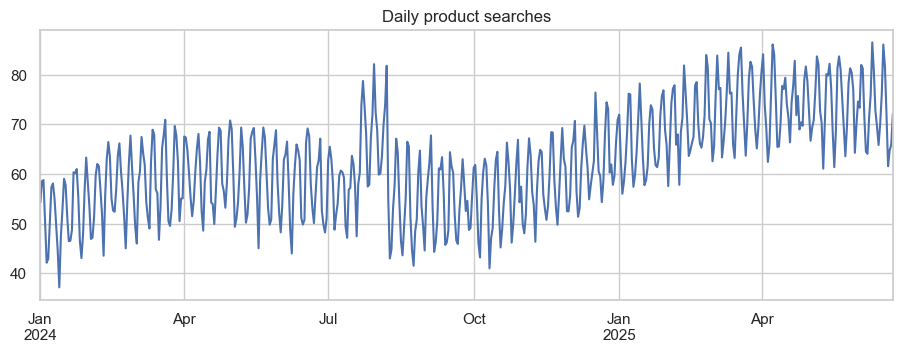

count    540.00
mean      62.45
std       10.14
min       37.21
25%       54.91
50%       62.38
75%       69.26
max       86.53
Name: searches, dtype: float64


In [3]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ts.plot(ax=ax); ax.set_title("Daily product searches"); plt.show()
print(ts.describe().round(2))

## 2. Diagnose first — is it stationary?

A series is **stationary** if its statistical properties (mean, variance, autocorrelation) don't change over time. Classical models (ARMA, ARIMA) require stationarity *after differencing*.

Two tests, used together:

| Test | Null hypothesis | If p < 0.05 |
|---|---|---|
| **ADF** (Augmented Dickey-Fuller) | non-stationary (has unit root) | series IS stationary |
| **KPSS** | stationary | series is NOT stationary |

Conflicting verdicts (both reject, or both fail to reject) are normal — that's why we always use both.


In [4]:
def stationarity_report(s, name="series"):
    adf_p  = adfuller(s.dropna(), autolag="AIC")[1]
    kpss_p = kpss(s.dropna(), regression="c", nlags="auto")[1]
    print(f"  {name:25s}  ADF p={adf_p:.4f}  KPSS p={kpss_p:.4f}  "
          f"→ {'stationary' if adf_p < 0.05 and kpss_p > 0.05 else 'NOT stationary'}")

stationarity_report(ts, "raw")
stationarity_report(ts.diff(),                       "1st diff")
stationarity_report(ts.diff().diff(7),               "1st diff + seasonal diff(7)")


  raw                        ADF p=0.4105  KPSS p=0.0100  → NOT stationary
  1st diff                   ADF p=0.0000  KPSS p=0.1000  → stationary
  1st diff + seasonal diff(7)  ADF p=0.0000  KPSS p=0.1000  → stationary


/var/folders/sz/1k1y5gg975j3mc23vxwrt0v40000gn/T/ipykernel_15913/3314024506.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s.dropna(), regression="c", nlags="auto")[1]
/var/folders/sz/1k1y5gg975j3mc23vxwrt0v40000gn/T/ipykernel_15913/3314024506.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(s.dropna(), regression="c", nlags="auto")[1]
/var/folders/sz/1k1y5gg975j3mc23vxwrt0v40000gn/T/ipykernel_15913/3314024506.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(s.dropna(), regression="c", nlags="auto")[1]


**Interpretation.** The raw series fails ADF (has a trend). After **first difference + seasonal difference at lag 7**, both tests agree it's stationary. That's our `(d, D) = (1, 1)` for the SARIMA spec below.


### 🔬 What *actually* happens when you difference a series?

Section 2 quietly did the most important move in classical forecasting: `ts.diff()`. The output above just said *"NOT stationary → stationary"*, but **why** does subtracting yesterday's value fix a trend? Let's slow it down — this is the whole "I" (Integrated) in AR**I**MA.

**The problem.** ARIMA (and ARMA, and the AR/MA pieces) assume the series is **stationary**: a constant mean, constant variance, and a "shape" that doesn't drift over time. A trending series breaks the very first rule — its mean keeps climbing, so the *average* depends on *when* you look:

```text
A TRENDED series — mean is NOT constant
value
  ↑                                   •
  │                            •  •         ← the mean keeps rising,
  │                     •  •                   so "the average" has no
  │              •  •                          single answer
  │       •  •
  │  •  •
  └──────────────────────────────────→ time
```

**The fix: model the CHANGES, not the LEVELS.** Instead of asking *"what is the value today?"* (which keeps growing), ask *"how much did it change since yesterday?"* — `y_t − y_{t-1}`, which in pandas is exactly `series.diff()`. For a straight-line trend, the *step* from one point to the next is roughly the same every day, so the differenced series wobbles around a **flat** mean:

```text
   trended line              after .diff()            flat line
        •                                              (the CHANGES
      •            ──  y_t − y_{t-1}  ──►        •  •    are constant-ish,
    •                                          •      •  so the mean
  •                                          •          stops drifting)
 ──────────────►                            ─────────────────►
   (mean drifts up)                          (mean ≈ flat → stationary)
```

That's the mental model: **differencing converts a level series into a change series, and a constant trend becomes a constant change — which is stationary.** The `d` in `SARIMA(p, d, q)` is just *how many times* you difference; the `D` is the same idea for the seasonal lag.

In [5]:
# 🧪 PROOF (offline): differencing strips a linear trend → flat mean
# Self-contained: builds its own trended series, no dependence on cells above.
import numpy as np
import pandas as pd

rng = np.random.default_rng(7)
n_demo   = 200
idx = pd.date_range("2024-01-01", periods=n_demo, freq="D")

# A clearly TRENDED series: rises ~0.5/day plus a little noise.
trend  = 0.5 * np.arange(n_demo)
level  = pd.Series(20 + trend + rng.normal(0, 1.0, n_demo), index=idx, name="level")

# The CHANGES: each value replaced by (today - yesterday).
change = level.diff()                       # = y_t - y_{t-1}; first value is NaN

In [6]:
# Compare the mean of the FIRST half vs the SECOND half of each series.
def half_means(s):
    s = s.dropna()
    h = len(s) // 2
    return s.iloc[:h].mean(), s.iloc[h:].mean()

lo_lvl, hi_lvl = half_means(level)
lo_chg, hi_chg = half_means(change)

print("LEVEL series (y_t)        — mean DRIFTS, so it is NOT stationary:")
print(f"   first-half mean = {lo_lvl:6.2f}   second-half mean = {hi_lvl:6.2f}"
      f"   → gap = {hi_lvl - lo_lvl:6.2f}")
print()
print("CHANGE series (y_t - y_t-1) after .diff() — mean is ~FLAT (stationary):")
print(f"   first-half mean = {lo_chg:6.2f}   second-half mean = {hi_chg:6.2f}"
      f"   → gap = {hi_chg - lo_chg:6.2f}")
print()
print(f"The trend's true slope was 0.5/day, and the differenced mean ≈ {change.mean():.2f}.")
print("That is exactly the trend: differencing turned 'climbing levels' into 'steady changes'.")

LEVEL series (y_t)        — mean DRIFTS, so it is NOT stationary:
   first-half mean =  44.58   second-half mean =  94.66   → gap =  50.08

CHANGE series (y_t - y_t-1) after .diff() — mean is ~FLAT (stationary):
   first-half mean =   0.48   second-half mean =   0.54   → gap =   0.06

The trend's true slope was 0.5/day, and the differenced mean ≈ 0.51.
That is exactly the trend: differencing turned 'climbing levels' into 'steady changes'.


> 👀 **See it.** The left panel keeps climbing — its mean depends on *when* you look. After `.diff()` the right panel just wobbles around a flat line: the trend is gone, and *that* is what "stationary" looks like.

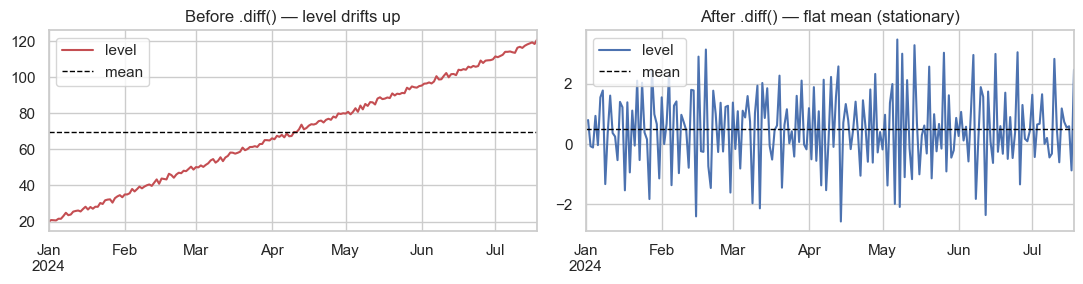

In [7]:
# 📊 The same data before and after .diff() — drifting levels vs flat changes
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 3.0))
level.plot(ax=axL, color="C3")
axL.axhline(level.mean(), ls="--", color="black", lw=1, label="mean")
axL.set_title("Before .diff() — level drifts up"); axL.legend(loc="upper left")
change.plot(ax=axR, color="C0")
axR.axhline(change.mean(), ls="--", color="black", lw=1, label="mean")
axR.set_title("After .diff() — flat mean (stationary)"); axR.legend(loc="upper left")
plt.tight_layout(); plt.show()

### 🔬 What is *autocorrelation*, really? (the ACF, by hand)

The next section (3) leans on the **ACF** — the *auto-correlation function*. "Auto" = *self*: it's just the ordinary correlation of the series **with a shifted copy of itself**. At **lag k** you line the series up against itself moved `k` steps, and measure how strongly they move together:

```text
series      :  y0  y1  y2  y3  y4  y5  y6  y7 ...
shifted (k=1):      y0  y1  y2  y3  y4  y5  y6 ...   ← compare overlapping pairs
                    └── corr(y_t, y_{t-1}) = ACF at lag 1
```

- A big ACF at **lag 1** → today looks a lot like yesterday (persistence).
- A big ACF at **lag 7** in daily data → today looks like *the same weekday last week* → **weekly seasonality**. This is the spike that tells you to seasonally difference at lag 7.

So the ACF is a **diagnostic map**: it shows *which past lags still carry signal* about the present, which is exactly what picks the model's orders. We compute it with `series.shift(k)` and `.corr()` — no library needed — then confirm against statsmodels' `acf`.

In [8]:
# 🧪 PROOF (offline): autocorrelation BY HAND = statsmodels acf
# Build a series with a strong WEEKLY (lag-7) pattern so the ACF spikes there.
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
n_demo   = 280
t   = np.arange(n_demo)
idx = pd.date_range("2024-01-01", periods=n_demo, freq="D")

weekly = 10 * np.sin(2 * np.pi * t / 7)            # repeats every 7 days
s      = pd.Series(weekly + rng.normal(0, 2, n_demo), index=idx, name="weekly_signal")

# Autocorrelation at lag k, BY HAND: corr(series, series shifted by k).
def autocorr_by_hand(series, k):
    return series.corr(series.shift(k))            # pandas aligns & drops the NaNs

In [9]:
print("lag k   by-hand corr(y_t, y_{t-k})")
print("-----   --------------------------")
for k in [1, 3, 6, 7, 14]:
    print(f"  {k:<5d}  {autocorr_by_hand(s, k):+.3f}")

print()
print("Notice: lag 7 and lag 14 are strongly POSITIVE (same weekday repeats),")
print("while lag 3 (half a week away) is strongly NEGATIVE. That lag-7 spike is")
print("the seasonality the ACF plot in Section 3 reveals.")

lag k   by-hand corr(y_t, y_{t-k})
-----   --------------------------
  1      +0.593
  3      -0.853
  6      +0.579
  7      +0.941
  14     +0.939

Notice: lag 7 and lag 14 are strongly POSITIVE (same weekday repeats),
while lag 3 (half a week away) is strongly NEGATIVE. That lag-7 spike is
the seasonality the ACF plot in Section 3 reveals.


In [10]:
# Cross-check against statsmodels' acf (same definition, vectorised).
from statsmodels.tsa.stattools import acf
acf_vals = acf(s, nlags=14, fft=False)
print()
print(f"by-hand lag 7 = {autocorr_by_hand(s, 7):+.3f}   "
      f"statsmodels acf lag 7 = {acf_vals[7]:+.3f}   (tiny diff = normalisation)")


by-hand lag 7 = +0.941   statsmodels acf lag 7 = +0.914   (tiny diff = normalisation)


> 🧠 **Mental model.** *ARIMA needs a stationary series. Differencing = model the **changes**, not the **levels** — which removes the trend. The ACF tells you which past lags still carry signal (e.g. a lag-7 spike = weekly seasonality).*

> 🎯 **Tie it back to the spec.** In `SARIMA(p, d, q)(P, D, Q, m)`: the **`d`** is "difference this many times to kill the trend" (`.diff()`), the **`D`** is the same for the seasonal lag (`.diff(7)`), and **`m`** is the season length (7 for weekly). The ACF/PACF plots next pick `p, q, P, Q`.

> ⚠️ **Don't over-difference.** Differencing once usually flattens a trend; differencing again and again *injects* artificial negative autocorrelation and inflates variance. Difference the *minimum* number of times the stationarity tests demand — here `(d, D) = (1, 1)` was enough. Watch for a large negative ACF at lag 1 as a warning sign of over-differencing.

---

### ✋ Quick exercise (~2 min) — One difference, or two?

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Section 2 used a first difference **and** a seasonal difference. A teammate insists a single seasonal difference at lag 7 is enough on its own. Run `stationarity_report` on a seasonal-only difference of `ts` and decide whether both tests agree it's stationary.

```python
ts.diff(7)   # seasonal difference at lag 7, no first difference
```

In [11]:
# ✍️ Your turn 👇
# Apply ONLY a seasonal difference at lag 7 (no first difference) and report stationarity.
stationarity_report(ts, "raw")              # baseline, for comparison
# stationarity_report(...)                  # <- your seasonal-only difference here

  raw                        ADF p=0.4105  KPSS p=0.0100  → NOT stationary


/var/folders/sz/1k1y5gg975j3mc23vxwrt0v40000gn/T/ipykernel_15913/3314024506.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s.dropna(), regression="c", nlags="auto")[1]


<details>
<summary>✅ <b>Solution</b></summary>

```python
stationarity_report(ts.diff(7), "seasonal diff(7) only")
```

A lag-7 difference subtracts the value from one week earlier, which removes the weekly cycle and (because the trend's weekly step is constant) much of the linear trend too — so the tests often already lean stationary. Section 2 still added the first difference to be safe, giving `(d, D) = (1, 1)`.
</details>

## 3. Read the ACF/PACF — the Box–Jenkins shortcut

The **ACF** (auto-correlation function) shows how the series correlates with its own lagged values. The **PACF** (partial ACF) removes the effect of shorter lags. Together they tell you the AR and MA orders.

| Pattern | Likely model |
|---|---|
| ACF tails off, PACF cuts off after p | **AR(p)** |
| ACF cuts off after q, PACF tails off | **MA(q)** |
| Both tail off | **ARMA(p, q)** |


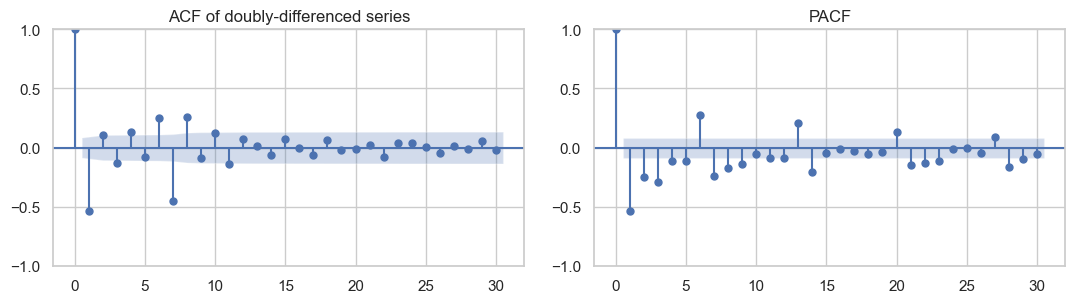

In [12]:
diff = ts.diff().diff(7).dropna()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.2))
plot_acf(diff, lags=30, ax=ax1); ax1.set_title("ACF of doubly-differenced series")
plot_pacf(diff, lags=30, ax=ax2, method="ywm"); ax2.set_title("PACF")
plt.tight_layout(); plt.show()


From the plots we see a spike at lag 7 (the seasonal effect) on both ACF and PACF — classic SARIMA territory. A reasonable first try: **SARIMA(1, 1, 1) × (1, 1, 1, 7)**.

In the notation `SARIMA(p, d, q) × (P, D, Q, m)`:
- `p, d, q` — non-seasonal AR order, differencing order, MA order
- `P, D, Q` — same for seasonal
- `m` — seasonal period (7 for weekly with daily data; 12 for monthly with monthly data; 24 for hourly daily-cycle)


## 4. Fit SARIMA with `statsmodels`


In [13]:
train = ts[:-30]; test = ts[-30:]

model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
                enforce_stationarity=False, enforce_invertibility=False)
res = model.fit(disp=False)
print(res.summary().tables[1])


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0316      0.047     -0.676      0.499      -0.123       0.060
ma.L1         -0.7224      0.038    -19.229      0.000      -0.796      -0.649
ar.S.L7        0.0967      0.052      1.864      0.062      -0.005       0.198
ma.S.L7       -1.0002      2.758     -0.363      0.717      -6.406       4.405
sigma2         9.0762     25.112      0.361      0.718     -40.141      58.294


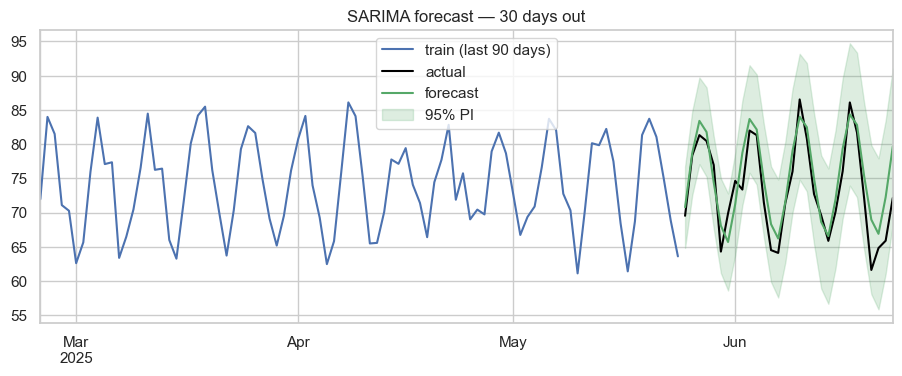

MAE  = 2.73     RMSE = 3.31


In [14]:
# Forecast 30 days with 95% intervals
fc = res.get_forecast(steps=len(test))
mean = fc.predicted_mean
ci   = fc.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(11, 3.8))
train[-90:].plot(ax=ax, label="train (last 90 days)")
test.plot(ax=ax, label="actual", color="black")
mean.plot(ax=ax, label="forecast", color="C2")
ax.fill_between(mean.index, ci.iloc[:, 0], ci.iloc[:, 1], color="C2", alpha=0.2,
                label="95% PI")
ax.legend(); ax.set_title("SARIMA forecast — 30 days out"); plt.show()

from sklearn.metrics import mean_absolute_error, mean_squared_error
mae  = mean_absolute_error(test, mean)
rmse = np.sqrt(mean_squared_error(test, mean))
print(f"MAE  = {mae:.2f}     RMSE = {rmse:.2f}")


---

### ✋ Quick exercise (~2 min) — Nudge the AR order

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Stakeholders ask whether a richer autoregressive part helps. Refit the SARIMA changing **only** the non-seasonal `order` from `(1, 1, 1)` to `(2, 1, 1)`, forecast the same 30 test days, and compute the MAE. Does it beat the original `mae` printed above?

In [15]:
# ✍️ Your turn 👇
# Same data and seasonal_order as Section 4 — only the non-seasonal `order` changes to (2, 1, 1).
model2 = SARIMAX(train, order=(2, 1, 1), seasonal_order=(1, 1, 1, 7),
                 enforce_stationarity=False, enforce_invertibility=False)
# res2 = model2.fit(disp=False)
# ... get_forecast for len(test) steps, then mean_absolute_error vs `test`

<details>
<summary>✅ <b>Solution</b></summary>

```python
res2  = SARIMAX(train, order=(2, 1, 1), seasonal_order=(1, 1, 1, 7),
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
mean2 = res2.get_forecast(steps=len(test)).predicted_mean
print(f"MAE (2,1,1) = {mean_absolute_error(test, mean2):.2f}   vs original {mae:.2f}")
```

Adding an extra AR lag rarely moves a well-specified model much — the original `ar.L1` term was already near zero (p ≈ 0.5), so the extra parameter mostly adds noise rather than accuracy.
</details>

## 5. Residual diagnostics — did we actually fit the noise?

A correctly-specified model leaves *no signal* in the residuals. The Ljung–Box test should NOT reject.


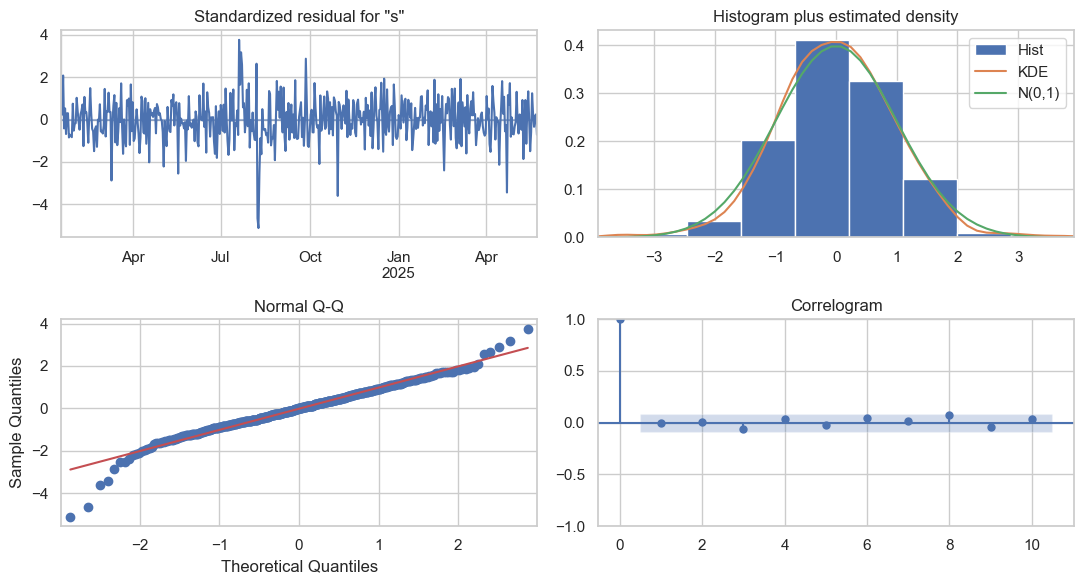

Ljung-Box (want p > 0.05):
    lb_stat  lb_pvalue
10  28.0891     0.0017
20  40.8587     0.0039


In [16]:
fig = res.plot_diagnostics(figsize=(11, 6)); plt.tight_layout(); plt.show()

from statsmodels.stats.diagnostic import acorr_ljungbox
lb = acorr_ljungbox(res.resid, lags=[10, 20], return_df=True)
print("Ljung-Box (want p > 0.05):")
print(lb.round(4))


## 6. ETS — exponential smoothing, modern state-space form

ETS = **Error**, **Trend**, **Seasonality**. Each component can be additive or multiplicative. Often *as accurate as* SARIMA, with fewer knobs.

| Component | Choices |
|---|---|
| Error (`E`) | additive (`A`), multiplicative (`M`) |
| Trend (`T`) | none (`N`), additive (`A`), damped additive (`Ad`) |
| Seasonality (`S`) | none (`N`), additive (`A`), multiplicative (`M`) |


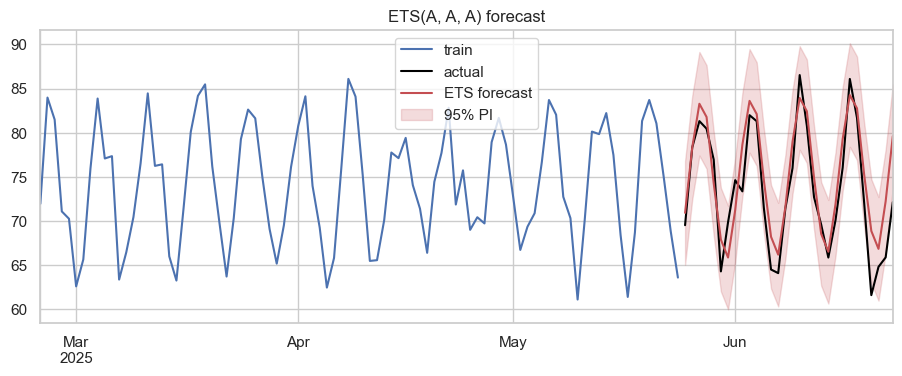

ETS  MAE = 2.69   RMSE = 3.27


In [17]:
ets = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=7)
fit = ets.fit(optimized=True, use_brute=True)
fc  = fit.forecast(steps=len(test))

# Bootstrap-ish prediction intervals via residual std
sigma = fit.resid.std()
lo, hi = fc - 1.96 * sigma, fc + 1.96 * sigma

fig, ax = plt.subplots(figsize=(11, 3.8))
train[-90:].plot(ax=ax, label="train")
test.plot(ax=ax, color="black", label="actual")
fc.plot(ax=ax, color="C3", label="ETS forecast")
ax.fill_between(fc.index, lo, hi, color="C3", alpha=0.2, label="95% PI")
ax.legend(); ax.set_title("ETS(A, A, A) forecast"); plt.show()

print(f"ETS  MAE = {mean_absolute_error(test, fc):.2f}   "
      f"RMSE = {np.sqrt(mean_squared_error(test, fc)):.2f}")


---

### ✋ Quick exercise (~2 min) — Damp the trend

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

A damped trend stops a forecast from extrapolating a straight line forever — handy when stakeholders distrust runaway growth. Refit the ETS model from Section 6 with `damped_trend=True`, forecast the 30 test days, and compute the MAE.

In [18]:
# ✍️ Your turn 👇
# Same components as Section 6, but ask for a damped trend.
ets_d = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=7,
                             damped_trend=True)
# fit (optimized), forecast len(test) steps, then mean_absolute_error vs `test`

<details>
<summary>✅ <b>Solution</b></summary>

```python
fit_d = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=7,
                             damped_trend=True).fit(optimized=True)
fc_d  = fit_d.forecast(steps=len(test))
print(f"ETS damped  MAE = {mean_absolute_error(test, fc_d):.2f}")
```

Damping multiplies the trend by a factor φ < 1 at each step, so the forecast flattens over the horizon — often safer for long horizons even when the short-horizon MAE barely changes.
</details>

## 7. Honest comparison — rolling-origin cross-validation

A single train/test split is a brittle benchmark — your forecast quality can vary by an order of magnitude across cuts of the data. The professional answer is **rolling-origin** (a.k.a. *time-series cross-validation*).


In [19]:
def rolling_eval(series, train_fn, horizon=14, n_splits=8, step=30):
    n = len(series)
    maes = []
    for k in range(n_splits):
        end_train = n - horizon - k * step
        if end_train < 60: break
        tr, te = series[:end_train], series[end_train:end_train + horizon]
        try:
            fc = train_fn(tr, horizon)
            maes.append(mean_absolute_error(te, fc))
        except Exception as e:
            maes.append(np.nan)
    return np.array(maes)

In [20]:
def fit_sarima(tr, h):
    m = SARIMAX(tr, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    return m.forecast(steps=h)

def fit_ets(tr, h):
    return ExponentialSmoothing(tr, trend="add", seasonal="add", seasonal_periods=7
            ).fit(optimized=True).forecast(steps=h)

def fit_naive(tr, h):     # seasonal naive — last week's pattern
    return pd.Series((tr.values[-7:].tolist() * (h // 7 + 1))[:h],
                     index=pd.date_range(tr.index[-1] + pd.Timedelta(days=1), periods=h))

In [21]:
mae_sar = rolling_eval(ts, fit_sarima)
mae_ets = rolling_eval(ts, fit_ets)
print(f"SARIMA  MAE = {np.nanmean(mae_sar):.2f} ± {np.nanstd(mae_sar):.2f}")
print(f"ETS     MAE = {np.nanmean(mae_ets):.2f} ± {np.nanstd(mae_ets):.2f}")

SARIMA  MAE = 2.18 ± 0.56
ETS     MAE = 2.16 ± 0.55


> 📊 **Look at the spread, not just the mean.** Each box shows the MAE across *all* rolling cuts — a tall box is an unstable model, exactly the risk the two summary numbers above hide.

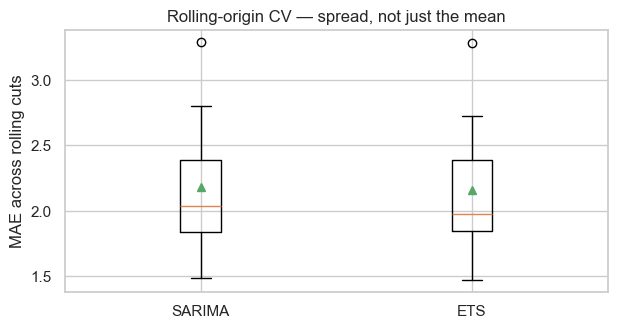

In [22]:
# 📊 Rolling-origin CV: the spread of per-cut MAE, not just the average
fig, ax = plt.subplots(figsize=(7, 3.4))
clean = [mae_sar[~np.isnan(mae_sar)], mae_ets[~np.isnan(mae_ets)]]
ax.boxplot(clean, showmeans=True)
ax.set_xticks([1, 2]); ax.set_xticklabels(["SARIMA", "ETS"])
ax.set_ylabel("MAE across rolling cuts")
ax.set_title("Rolling-origin CV — spread, not just the mean")
plt.show()

**Reading the result.** Look at *both* the mean AND the standard deviation. A model that wins on average but is unstable across cuts is risky — and *that* is what rolling-origin reveals.


---

### ✋ Quick exercise (~2 min) — Is the baseline really worse?

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Before trusting SARIMA/ETS, always beat a dumb baseline. Use the `rolling_eval` helper to score the seasonal-naive forecast `fit_naive` (last week's pattern, defined above) and compare its mean ± std MAE to the SARIMA and ETS numbers just printed.

In [23]:
# ✍️ Your turn 👇
# `rolling_eval` and `fit_naive` (seasonal naive) are already defined in this section.
mae_naive = rolling_eval(ts, fit_naive)
# print the mean ± std and compare to the SARIMA / ETS numbers above

<details>
<summary>✅ <b>Solution</b></summary>

```python
mae_naive = rolling_eval(ts, fit_naive)
print(f"seasonal-naive  MAE = {np.nanmean(mae_naive):.2f} ± {np.nanstd(mae_naive):.2f}")
```

If the naive baseline's mean MAE is close to SARIMA/ETS, the extra model complexity is buying little — rolling-origin CV is exactly what exposes that honestly.
</details>

## 8. Decision rubric — pick a classical model

```
1. Plot the series.  Trend?  Seasonality?  Outliers?
2. Test for stationarity (ADF + KPSS).  Difference until stationary.
3. Read ACF/PACF on the differenced series to guess (p, q).
4. Fit SARIMA(p, d, q)(P, D, Q, m) AND ETS — they have different strengths.
5. Evaluate with rolling-origin CV.  Pick the lower-mean, lower-variance one.
6. Check residuals (Ljung-Box).  If still autocorrelated, raise (p) or (P).
```

When SARIMA usually wins: strong autocorrelation, complex seasonality, need explainable coefficients.
When ETS usually wins: smooth, dominantly trend-driven series; fewer parameters to tune.


## 🧪 Exercises

### Exercise 1 — Add a regressor (`SARIMAX`'s "X")
Add a binary `promo` indicator series and fit a `SARIMAX` with `exog=promo`. Does the AIC drop? Are the residual ACFs cleaner?


In [24]:
# ── Exercise 1 solution ──────────────────────────────────────────────────
promo_indicator = pd.Series(np.where((np.arange(n) > 200) & (np.arange(n) < 220), 1, 0),
                            index=dates)

train_x, test_x = promo_indicator[:-30], promo_indicator[-30:]
model_x = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
                  exog=train_x, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
print(f"SARIMA   AIC = {res.aic:.1f}")
print(f"SARIMAX  AIC = {model_x.aic:.1f}  ← lower is better")
fc_x = model_x.get_forecast(steps=len(test), exog=test_x.values.reshape(-1, 1)).predicted_mean
print(f"MAE without exog: {mean_absolute_error(test, mean):.2f}")
print(f"MAE with exog:    {mean_absolute_error(test, fc_x):.2f}")


SARIMA   AIC = 2525.4
SARIMAX  AIC = 2412.5  ← lower is better
MAE without exog: 2.73
MAE with exog:    2.82


### Exercise 2 — Auto-search for the best `(p, d, q)`
Without using `pmdarima`, write a small grid search over `p, q ∈ {0,1,2}` and `P, Q ∈ {0,1}` that picks the SARIMA with the lowest **AIC**. Report which order won and re-run the rolling-origin evaluation on it.


In [25]:
# ── Exercise 2 solution ──────────────────────────────────────────────────
best, best_aic = None, np.inf
for p in range(3):
    for q in range(3):
        for P in range(2):
            for Q in range(2):
                try:
                    m = SARIMAX(train, order=(p, 1, q), seasonal_order=(P, 1, Q, 7),
                                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                    if m.aic < best_aic:
                        best, best_aic = (p, 1, q, P, 1, Q, 7), m.aic
                except Exception:
                    pass
print(f"best order: SARIMA{best[:3]} x {best[3:]}  AIC={best_aic:.1f}")
def fit_best(tr, h):
    p, d, q, P, D, Q, m = best
    return SARIMAX(tr, order=(p, d, q), seasonal_order=(P, D, Q, m),
                   enforce_stationarity=False, enforce_invertibility=False
                   ).fit(disp=False).forecast(steps=h)
mae_best = rolling_eval(ts, fit_best)
print(f"best-grid  MAE = {np.nanmean(mae_best):.2f} ± {np.nanstd(mae_best):.2f}")


best order: SARIMA(1, 1, 2) x (1, 1, 1, 7)  AIC=2517.7


best-grid  MAE = 2.16 ± 0.57


## 🧠 Key takeaways

- Diagnose **before** modelling. ADF + KPSS for stationarity; ACF + PACF for orders.
- `SARIMAX(p, d, q)(P, D, Q, m)` and `ExponentialSmoothing(E, T, S)` cover 90 % of classical use cases.
- Use **rolling-origin CV** to compare honestly — a single split overestimates by a lot.
- Always check **residuals**. A clean Ljung-Box test is a non-negotiable sanity check.

## 🚀 Next step

[`A2_forecasting_prophet_libraries.ipynb`](./A2_forecasting_prophet_libraries.ipynb) — Prophet, NeuralProphet, sktime, Darts.
